1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


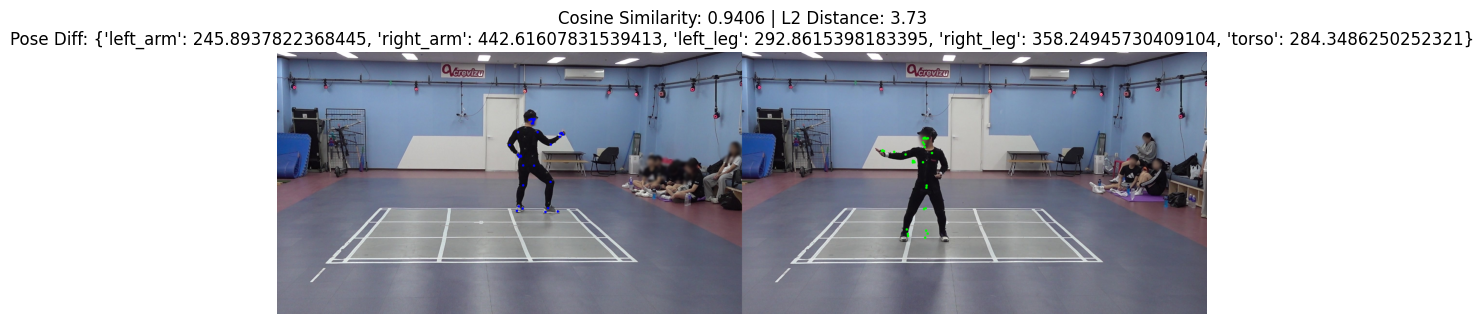

In [6]:
import os
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input

# ===========================
# ⚙️ Step 1: Mediapipe Pose Extraction
# ===========================
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True)
mp_drawing = mp.solutions.drawing_utils

def extract_mediapipe_pose(image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"cv2.imread failed to load image at: {image_path}")
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose.process(image_rgb)
    
    if not results.pose_landmarks:
        return None, image

    height, width = image.shape[:2]
    keypoints = {}
    for idx, lm in enumerate(results.pose_landmarks.landmark):
        keypoints[str(idx)] = np.array([lm.x * width, lm.y * height])
    return keypoints, image

# ===========================
# ⚙️ Step 2: Feature Extraction using EfficientNetB4
# ===========================
def extract_feature_vector(image_path, model):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"cv2.imread failed to load image at: {image_path}")
    image = cv2.resize(image, (380, 380))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = preprocess_input(image.astype(np.float32))
    image = np.expand_dims(image, axis=0)
    feature = model.predict(image)
    return feature

# ===========================
# ⚙️ Step 3: Part-wise Pose Similarity
# ===========================
POSE_PARTS = {
    "left_arm": [11, 13, 15],
    "right_arm": [12, 14, 16],
    "left_leg": [23, 25, 27],
    "right_leg": [24, 26, 28],
    "torso": [11, 12, 23, 24]
}

def compute_pose_similarity(user_pose, ref_pose):
    if user_pose is None or ref_pose is None:
        return None
    similarity = {}
    for part, indices in POSE_PARTS.items():
        distances = []
        for idx in indices:
            kp = str(idx)
            if kp in user_pose and kp in ref_pose:
                distances.append(np.linalg.norm(user_pose[kp] - ref_pose[kp]))
        similarity[part] = float(np.mean(distances)) if distances else None
    return similarity

# ===========================
# ⚙️ Step 4: Visualize Pose Comparison
# ===========================
def visualize_pose(image, pose_kps, color=(0, 255, 0)):
    if pose_kps is None:
        return image
    for point in pose_kps.values():
        cv2.circle(image, tuple(np.round(point).astype(int)), 5, color, -1)
    return image

# ===========================
# 🧪 Example Pipeline Execution
# ===========================
if __name__ == "__main__":
    # Load EfficientNetB4 feature extractor
    feature_model = EfficientNetB4(include_top=False, weights='imagenet', pooling='avg')
    
    # Replace these with your actual paths
    ref_image_path = "blackbelt_E/5/KR_E_2D_0978.jpg"
    user_image_path = "blackbelt_H/17/KR_H_2D_2611.jpg"

    # 1. Extract poses
    ref_pose, ref_img = extract_mediapipe_pose(ref_image_path)
    user_pose, user_img = extract_mediapipe_pose(user_image_path)

    # 2. Compare pose similarity (part-wise)
    pose_diff = compute_pose_similarity(user_pose, ref_pose)

    # 3. Extract feature vectors & compute image similarity
    ref_vec = extract_feature_vector(ref_image_path, feature_model)
    user_vec = extract_feature_vector(user_image_path, feature_model)
    cos_sim = cosine_similarity(ref_vec, user_vec)[0][0]
    l2_dist = float(np.linalg.norm(ref_vec - user_vec))

    # 4. Visualize result side-by-side
    annotated_ref  = visualize_pose(ref_img.copy(),  ref_pose,  color=(255, 0,   0))
    annotated_user = visualize_pose(user_img.copy(), user_pose, color=(0,   255, 0))
    comparison_image = np.hstack((annotated_ref, annotated_user))

    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(comparison_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(
        f"Cosine Similarity: {cos_sim:.4f} | L2 Distance: {l2_dist:.2f}\n"
        f"Pose Diff: {pose_diff}"
    )
    plt.show()
  


In [7]:
# Re-import necessary libraries after code execution environment was reset
import os
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model

# ===========================
# ⚙️ Step 1: Mediapipe Pose Extraction
# ===========================
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True)
mp_drawing = mp.solutions.drawing_utils

def extract_mediapipe_pose(image_path):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose.process(image_rgb)
    
    if not results.pose_landmarks:
        return None, image

    height, width = image.shape[:2]
    keypoints = {}
    for idx, lm in enumerate(results.pose_landmarks.landmark):
        keypoints[f"{idx}"] = np.array([lm.x * width, lm.y * height])
    return keypoints, image

# ===========================
# ⚙️ Step 2: Feature Extraction using EfficientNetB4
# ===========================
def extract_feature_vector(image_path, model):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (380, 380))
    image = preprocess_input(image.astype(np.float32))
    image = np.expand_dims(image, axis=0)
    feature = model.predict(image)
    return feature

# ===========================
# ⚙️ Step 3: Part-wise Pose Similarity
# ===========================
POSE_PARTS = {
    "left_arm": [11, 13, 15],
    "right_arm": [12, 14, 16],
    "left_leg": [23, 25, 27],
    "right_leg": [24, 26, 28],
    "torso": [11, 12, 23, 24]
}

def compute_pose_similarity(user_pose, ref_pose):
    similarity = {}
    for part, indices in POSE_PARTS.items():
        distances = []
        for idx in indices:
            if str(idx) in user_pose and str(idx) in ref_pose:
                dist = np.linalg.norm(user_pose[str(idx)] - ref_pose[str(idx)])
                distances.append(dist)
        similarity[part] = np.mean(distances) if distances else None
    return similarity

# ===========================
# ⚙️ Step 4: Visualize Pose Comparison
# ===========================
def visualize_pose(image, pose_kps, color=(0, 255, 0)):
    for point in pose_kps.values():
        cv2.circle(image, tuple(np.round(point).astype(int)), 5, color, -1)
    return image


1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step


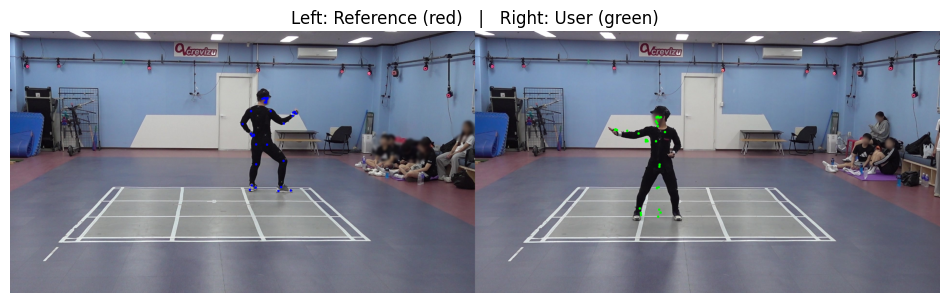

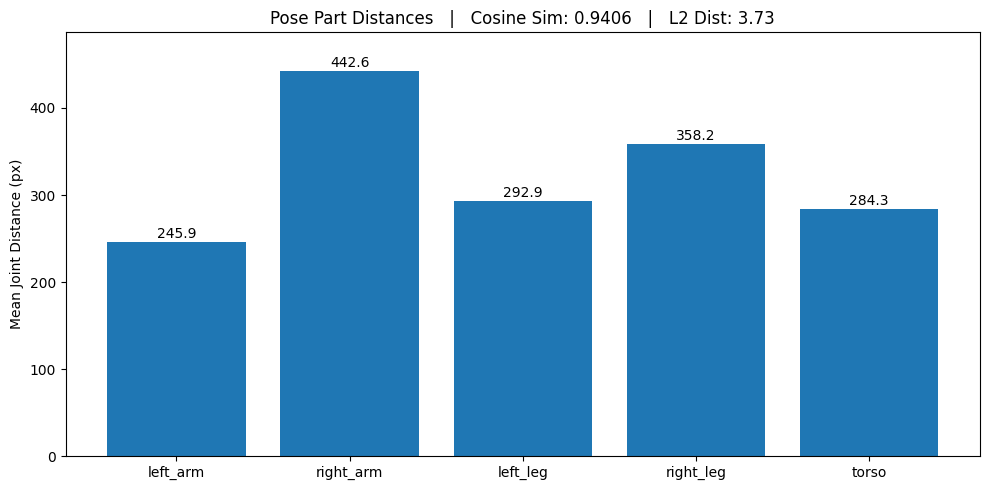

In [9]:
import os
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input

# ===========================
# ⚙️ Step 1: Mediapipe Pose Extraction
# ===========================
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True)

def extract_mediapipe_pose(image_path):
    """이미지에서 MediaPipe로 33개 관절 좌표 추출"""
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Failed to load image: {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = pose.process(img_rgb)

    if not results.pose_landmarks:
        return None, img

    h, w = img.shape[:2]
    keypoints = {
        str(i): np.array([lm.x * w, lm.y * h])
        for i, lm in enumerate(results.pose_landmarks.landmark)
    }
    return keypoints, img

# ===========================
# ⚙️ Step 2: Feature Extraction using EfficientNetB4
# ===========================
def extract_feature_vector(image_path, model):
    """EfficientNetB4로 이미지 특징벡터 추출"""
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Failed to load image: {image_path}")
    img = cv2.resize(img, (380, 380))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = preprocess_input(img.astype(np.float32))
    img = np.expand_dims(img, axis=0)
    return model.predict(img)

# ===========================
# ⚙️ Step 3: Part-wise Pose Similarity
# ===========================
POSE_PARTS = {
    "left_arm":  [11, 13, 15],
    "right_arm": [12, 14, 16],
    "left_leg":  [23, 25, 27],
    "right_leg": [24, 26, 28],
    "torso":     [11, 12, 23, 24]
}

def compute_pose_similarity(user_pose, ref_pose):
    """파트별 평균 관절 거리 계산"""
    if user_pose is None or ref_pose is None:
        return None
    sim = {}
    for part, idxs in POSE_PARTS.items():
        dists = []
        for i in idxs:
            k = str(i)
            if k in user_pose and k in ref_pose:
                dists.append(np.linalg.norm(user_pose[k] - ref_pose[k]))
        sim[part] = float(np.mean(dists)) if dists else None
    return sim

# ===========================
# ⚙️ Step 4: Visualize Pose on Image
# ===========================
def visualize_pose(image, kps, color=(0,255,0)):
    """관절 좌표를 이미지에 점으로 표시"""
    if kps is None:
        return image
    for pt in kps.values():
        cv2.circle(image, tuple(np.round(pt).astype(int)), 5, color, -1)
    return image

# ===========================
# ⚙️ Step 5: Similarity Plotting
# ===========================
def plot_similarity(pose_diff, cos_sim, l2_dist):
    """파트별 거리와 전체 유사도(코사인·L2) 막대그래프"""
    parts = list(pose_diff.keys())
    diffs = [pose_diff[p] or 0 for p in parts]

    plt.figure(figsize=(10,5))
    bars = plt.bar(parts, diffs)
    plt.ylabel("Mean Joint Distance (px)")
    plt.ylim(0, max(diffs)*1.1)
    plt.title(f"Pose Part Distances   |   Cosine Sim: {cos_sim:.4f}   |   L2 Dist: {l2_dist:.2f}")

    for bar, d in zip(bars, diffs):
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f"{d:.1f}",
                 ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

# ===========================
# 🧪 Main Pipeline
# ===========================
if __name__ == "__main__":
    # 1) 모델 로드
    feature_model = EfficientNetB4(include_top=False, weights='imagenet', pooling='avg')

    # 2) 비교할 이미지 경로
    ref_image_path  = "blackbelt_E/5/KR_E_2D_0978.jpg"
    user_image_path = "blackbelt_H/17/KR_H_2D_2611.jpg"

    # 3) 관절 & 원본 이미지 읽기
    ref_pose,  ref_img  = extract_mediapipe_pose(ref_image_path)
    user_pose, user_img = extract_mediapipe_pose(user_image_path)

    # 4) 파트별 포즈 차이
    pose_diff = compute_pose_similarity(user_pose, ref_pose)

    # 5) 특징 벡터 & 이미지 유사도
    ref_vec  = extract_feature_vector(ref_image_path, feature_model)
    user_vec = extract_feature_vector(user_image_path, feature_model)
    cos_sim  = cosine_similarity(ref_vec, user_vec)[0][0]
    l2_dist  = float(np.linalg.norm(ref_vec - user_vec))

    # 6) 포즈 비교 이미지 생성
    ann_ref  = visualize_pose(ref_img.copy(),  ref_pose,  color=(255,0,0))
    ann_user = visualize_pose(user_img.copy(), user_pose, color=(0,255,0))
    comp_img = np.hstack((ann_ref, ann_user))

    plt.figure(figsize=(12,6))
    plt.imshow(cv2.cvtColor(comp_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Left: Reference (red)   |   Right: User (green)")
    plt.show()

    # 7) 파트별 & 전체 유사도 시각화
    plot_similarity(pose_diff, cos_sim, l2_dist)


### Efficientnetb4 모델, Vit 모델 비교

In [11]:
! pip install transformers torch pillow

  Using cached regex-2024.11.6-cp310-cp310-win_amd64.whl (274 kB)
  Using cached tokenizers-0.21.1-cp39-abi3-win_amd64.whl (2.4 MB)
  Using cached filelock-3.18.0-py3-none-any.whl (16 kB)
  Using cached PyYAML-6.0.2-cp310-cp310-win_amd64.whl (161 kB)
  Using cached safetensors-0.5.3-cp38-abi3-win_amd64.whl (308 kB)
  Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)
  Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)


You should consider upgrading via the 'C:\Users\LG\taekwondo_forms\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


c:\Users\LG\taekwondo_forms\.venv\lib\site-packages\transformers\models\vit\feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step


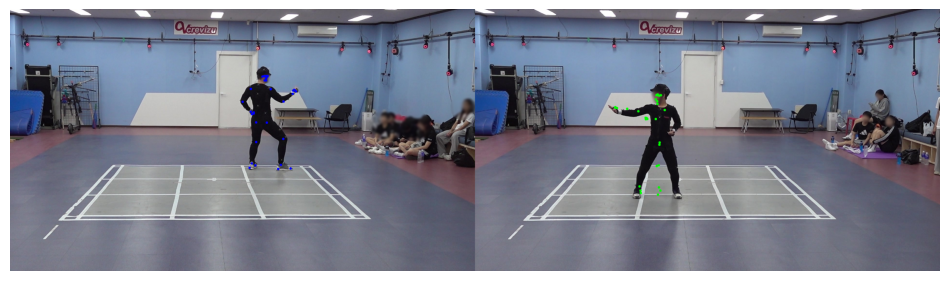

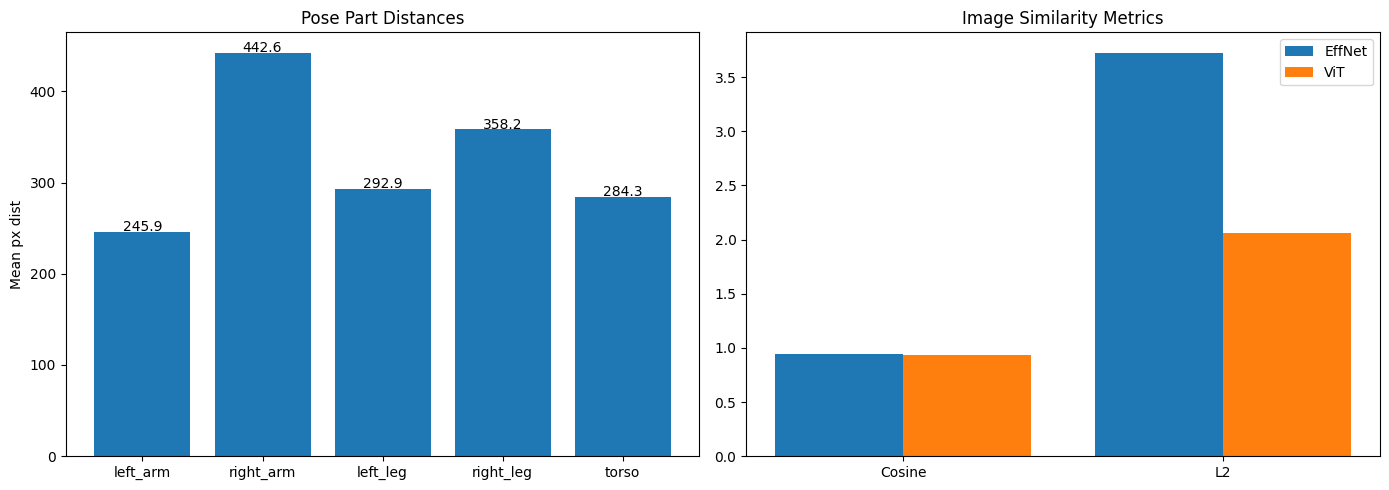

In [13]:
import os
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from transformers import ViTModel, ViTFeatureExtractor

# =====================================
# 🧩 1. MediaPipe Pose Extraction
# =====================================
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True)

# Pose-part indices
POSE_PARTS = {
    "left_arm":  [11, 13, 15],
    "right_arm": [12, 14, 16],
    "left_leg":  [23, 25, 27],
    "right_leg": [24, 26, 28],
    "torso":     [11, 12, 23, 24]
}

def extract_pose_kps(image_path):
    if not os.path.exists(image_path): raise FileNotFoundError(f"No image: {image_path}")
    img = cv2.imread(image_path)
    if img is None: raise ValueError(f"Fail load: {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    res = pose.process(img_rgb)
    if not res.pose_landmarks: return None, img
    h, w = img.shape[:2]
    kps = {str(i): np.array([lm.x*w, lm.y*h]) for i, lm in enumerate(res.pose_landmarks.landmark)}
    return kps, img

# =====================================
# 🧩 2. EfficientNetB4 Feature Extractor
# =====================================
def build_effnet_model():
    base = EfficientNetB4(include_top=False, weights='imagenet', pooling='avg')
    return base

def extract_effnet_feats(image_path, model):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (380,380))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = preprocess_input(img.astype(np.float32))
    img = np.expand_dims(img,0)
    return model.predict(img)

# =====================================
# 🧩 3. Vision Transformer Feature Extractor
# =====================================
def build_vit_model():
    fe = ViTFeatureExtractor.from_pretrained('google/vit-base-patch16-224-in21k')
    m = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')
    return fe, m

def extract_vit_feats(image_path, feature_extractor, model):
    from PIL import Image
    img = Image.open(image_path).convert('RGB')
    inputs = feature_extractor(images=img, return_tensors='pt')
    out = model(**inputs)
    # use CLS token
    return out.last_hidden_state[:,0,:].detach().numpy()

# =====================================
# 🧩 4. Pose Similarity Computation
# =====================================
def compute_pose_similarity(user_kps, ref_kps):
    if user_kps is None or ref_kps is None: return None
    res = {}
    for part, idxs in POSE_PARTS.items():
        ds = [np.linalg.norm(user_kps[str(i)]-ref_kps[str(i)]) \
              for i in idxs if str(i) in user_kps and str(i) in ref_kps]
        res[part] = float(np.mean(ds)) if ds else None
    return res

# =====================================
# 🧩 5. Similarity Metrics
# =====================================
def compute_metrics(ref_vec, user_vec):
    cos = cosine_similarity(ref_vec, user_vec)[0][0]
    l2  = float(np.linalg.norm(ref_vec-user_vec))
    return cos, l2

# =====================================
# 🧩 6. Plotting
# =====================================
def visualize_pose(img, kps, color):
    out = img.copy()
    if kps:
        for p in kps.values(): cv2.circle(out, tuple(p.astype(int)), 5, color, -1)
    return out


def plot_comparison(pose_diff, eff_metrics, vit_metrics):
    parts = list(pose_diff.keys())
    diffs = [pose_diff[p] or 0 for p in parts]

    fig, ax = plt.subplots(1,2, figsize=(14,5))

    # Part distances
    bars = ax[0].bar(parts, diffs)
    ax[0].set_title('Pose Part Distances')
    ax[0].set_ylabel('Mean px dist')
    for b,d in zip(bars, diffs): ax[0].text(b.get_x()+b.get_width()/2, d+1, f'{d:.1f}', ha='center')

    # Model metrics
    labels = ['Cosine','L2']
    x = np.arange(2)
    ax[1].bar(x-0.2, eff_metrics, width=0.4, label='EffNet')
    ax[1].bar(x+0.2, vit_metrics, width=0.4, label='ViT')
    ax[1].set_xticks(x)
    ax[1].set_xticklabels(labels)
    ax[1].legend()
    ax[1].set_title('Image Similarity Metrics')

    plt.tight_layout()
    plt.show()

# =====================================
# 🧪 7. Main Execution
# =====================================
if __name__ == '__main__':
    # Paths
    ref_path  = 'blackbelt_E/5/KR_E_2D_0978.jpg'
    user_path = 'blackbelt_H/17/KR_H_2D_2611.jpg'

    # Build models
    eff_model = build_effnet_model()
    vit_fe, vit_model = build_vit_model()

    # Extract pose
    ref_kps, ref_img  = extract_pose_kps(ref_path)
    usr_kps, usr_img  = extract_pose_kps(user_path)

    # Pose similarity
    pose_diff = compute_pose_similarity(usr_kps, ref_kps)

    # Feature vectors
    eff_ref_vec  = extract_effnet_feats(ref_path, eff_model)
    eff_usr_vec  = extract_effnet_feats(user_path, eff_model)
    vit_ref_vec, vit_usr_vec = extract_vit_feats(ref_path, vit_fe, vit_model), extract_vit_feats(user_path, vit_fe, vit_model)

    # Metrics
    eff_cos, eff_l2 = compute_metrics(eff_ref_vec, eff_usr_vec)
    vit_cos, vit_l2 = compute_metrics(vit_ref_vec, vit_usr_vec)

    # Visualization
    comp = np.hstack((visualize_pose(ref_img, ref_kps, (255,0,0)), visualize_pose(usr_img, usr_kps, (0,255,0))))
    plt.figure(figsize=(12,6)); plt.imshow(cv2.cvtColor(comp, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.show()

    # Comparison plot
    plot_comparison(pose_diff, (eff_cos, eff_l2), (vit_cos, vit_l2))


In [ ]:
# test_web2_transformer.py

import os
import cv2
import numpy as np
import streamlit as st
from PIL import Image
import mediapipe as mp
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity

# ===============================
# 1) MediaPipe Pose 초기화
# ===============================
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

def extract_keypoints(img: Image.Image) -> np.ndarray:
    """PIL 이미지를 받아서 33관절 (x,y) 좌표 배열 (33×2,) 반환"""
    img_np = np.array(img.convert("RGB"))
    res = pose.process(img_np)
    if not res.pose_landmarks:
        return None
    lm = res.pose_landmarks.landmark
    pts = np.array([[p.x, p.y] for p in lm], dtype=np.float32)  # (33,2)
    return pts

# ===============================
# 2) Transformer Encoder 정의
# ===============================
class PoseTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, nlayers=2):
        super().__init__()
        self.input_proj = nn.Linear(2, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model,
                                                   nhead=nhead,
                                                   dim_feedforward=d_model*2,
                                                   dropout=0.1,
                                                   activation="gelu")
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
        self.pool   = nn.Linear(d_model, d_model)  # CLS 대신 평균풀링 후 프로젝션

    def forward(self, keypoints: torch.Tensor) -> torch.Tensor:
        # keypoints: (batch=1, num_joints=33, 2)
        x = self.input_proj(keypoints)            # -> (1,33,d_model)
        # Transformer expects (S, B, E)
        x = x.permute(1, 0, 2)                     # -> (33,1,d_model)
        x = self.encoder(x)                        # -> (33,1,d_model)
        x = x.mean(dim=0)                          # -> (1,d_model)
        return F.normalize(self.pool(x), dim=-1)   # -> (1,d_model), L2 정규화

# ===============================
# 3) 기준 폼 임베딩 미리 계산
# ===============================
@st.cache_resource
def load_reference_embeddings(ref_dir: str, model: PoseTransformer):
    """폴더별로 정석 이미지 읽어와서 (class_name→embedding) dict 생성"""
    embeddings, labels = [], []
    for class_name in sorted(os.listdir(ref_dir)):
        cls_dir = os.path.join(ref_dir, class_name)
        if not os.path.isdir(cls_dir): continue
        # 모든 이미지 중 한 가지(또는 평균) 사용
        img_files = [f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg",".png"))]
        if not img_files: continue
        pts = extract_keypoints(Image.open(os.path.join(cls_dir, img_files[0])))
        if pts is None: continue
        with torch.no_grad():
            emb = model(torch.from_numpy(pts[None]).float()).cpu().numpy()  # (1,d)
        embeddings.append(emb.flatten())
        labels.append(class_name)
    return np.vstack(embeddings), labels

# ===============================
# 4) Streamlit UI
# ===============================
st.title("🥋 Transformer 기반 Taekwondo 폼 유사도 측정")

# 4.1) 모델 준비
device = "cuda" if torch.cuda.is_available() else "cpu"
model = PoseTransformer().to(device).eval()

# 4.2) 기준 임베딩 로드 (한 번만)
REF_DIR = "taekwon_form"  # 내부에 blackbelt_E, blackbelt_H, … 폴더 구조
ref_embs, ref_labels = load_reference_embeddings(REF_DIR, model)

# 4.3) 이미지 업로드
user_file = st.file_uploader("📥 사용자 이미지", type=["jpg","png","jpeg"])
if user_file:
    user_img = Image.open(user_file)
    st.image(user_img, caption="사용자 자세", width=400)
    pts = extract_keypoints(user_img)
    if pts is None:
        st.error("인물이 잘 보여야 합니다.")
    else:
        # 4.4) 사용자 임베딩 계산
        with torch.no_grad():
            user_emb = model(torch.from_numpy(pts[None]).float().to(device)).cpu().numpy()  # (1,d)

        # 4.5) Cosine 유사도 계산
        sims = cosine_similarity(user_emb, ref_embs)[0]  # (n_classes,)
        best_idx = int(np.argmax(sims))
        best_label = ref_labels[best_idx]
        best_sim   = sims[best_idx]

        # 4.6) 결과 출력 포맷
        # → "예측 품새: 17번   |   유사도: 99.95%"
        st.success(f"✅ 예측 폼: {best_label}번   |   유사도: {best_sim*100:.2f}%")
        st.markdown("---")
        st.write("### 🔍 세부 유사도 리스트")
        for lbl, sim in zip(ref_labels, sims):
            st.write(f"- {lbl}번: {sim*100:.2f}%")

        # (선택) 사용자가 올린 이미지를 기준 폼 위에 겹쳐 보여주기
        # ...

